In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm
from scipy.stats import percentileofscore
import scipy
import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


In [2]:
# land/sea mask
ECHAM5_land_mask = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/fx/atmos/sftlf/ens00/sftlf_fx_ECHAM5-4_All-Hist_est1_v1-0_ens00_000000-000000.nc')
ECHAM5_land_mask = ECHAM5_land_mask.sel(lon = slice(165,180),lat=slice(-33,-48))

seasons_a = ['autumn','winter','spring','summer']

In [3]:
def q_map_to_gaussian(da, dist):
    
    # create container for gaussian values
    gaussian = []
    
    for lat in da.lat:
        for lon in da.lon:

            ts = da.sel(lat=lat,lon=lon).values
            full_dist = dist.sel(lat=lat,lon=lon).values
            
            if np.isnan(np.sum(ts)):
                corrected_ts = [np.nan for i in range(len(ts))]

            else:
                corrected_ts = []
                for val in ts:
                    
                    # find percentile of value within the distribution of observations
                    percentile = percentileofscore(full_dist, val, kind= 'mean')
                    
                    if percentile == 100 or percentile == 0:
                        print('issue')

                    # replace with corresponding percentile value in norm distribution
                    corrected_ts.append(scipy.stats.norm.ppf(percentile/100, loc=0, scale=1))

            gaussian.append(corrected_ts)

    gaussian = np.array(gaussian).reshape((len(da.lat),len(da.lon),len(da.time)))
    
    gaussian_da = xr.DataArray(data = gaussian,
                               dims = ('lat', 'lon','time'),
                               coords = {'lat':da.lat.values,
                                         'lon':da.lon.values,
                                         'time':da.time.values
                                        }
                               )
    return(gaussian_da)


In [5]:
'''
Creating dataarrays of full ensemble distributions (concatenate all ensemble members over time)
'''

# SEASONAL
path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/tasmax/ens'
file_name_setup = ['tasmax_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']

# {('all','winter'):full ensemble distribution dataarray}
scen_season_dict = {}
for scen in ['all','nat']:
    
    if scen == 'all':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
    if scen == 'nat':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202102.nc']
        
    for i,s in enumerate([3,6,9,12]):

        da_list = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
            ens_mem = xr.open_dataset(file_path)

            ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
            ens_mem = ens_mem.tasmax.where(ECHAM5_land_mask.sftlf > 0)

            ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
            ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))

            ens_mem.close()
            
            ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

            da_list.append(ens_mem_season)

        season_full_dist = xr.concat(da_list,dim="time")
        scen_season_dict[(scen,seasons_a[i])] = season_full_dist
    

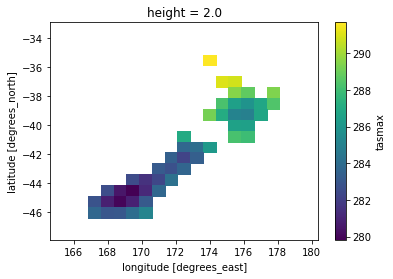

In [23]:
(2019-1979+1)*50

2050

In [12]:
'''
Gaussianify by q-mapping local time series to normal distribution using full ensemble distributions
'''

seasons_a = ['autumn','winter','spring','summer']


for scen in ['all','nat']:
    print(scen)

    if scen == 'all':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
    if scen == 'nat':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202102.nc']

    for ens_mem in range(1,51):
        
        print(ens_mem)
        
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        ens_mem = xr.open_dataset(file_path)
        
        ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
        ens_mem = ens_mem.tasmax.where(ECHAM5_land_mask.sftlf > 0)

        ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
        ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))
        
        ens_mem.close()
        for i,s in enumerate([3,6,9,12]):
            
            print(seasons_a[i])
            
            ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

            ens_mem_season_gaussian = q_map_to_gaussian(ens_mem_season,scen_season_dict[(scen,seasons_a[i])])
            ens_mem_season_gaussian.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_"+scen+"_"+seasons_a[i]+"_tasmax_gaussian_ens"+number+".nc")

            ens_mem_season.close()
            ens_mem_season_gaussian.close()
            
        ens_mem_seasonal.close()
        
        

all
1
autumn
winter
spring
summer
2
autumn
winter
spring
summer
3
autumn
winter
spring
summer
4
autumn
winter
spring
summer
5
autumn
winter
spring
summer
6
autumn
winter
spring
summer
7
autumn
winter
spring
summer
8
autumn
winter
spring
summer
9
autumn
winter
spring
summer
10
autumn
winter
spring
summer
11
autumn
winter
spring
summer
12
autumn
winter
spring
summer
13
autumn
winter
spring
summer
14
autumn
winter
spring
summer
15
autumn
winter
spring
summer
16
autumn
winter
spring
summer
17
autumn
winter
spring
summer
18
autumn
winter
spring
summer
19
autumn
winter
spring
summer
20
autumn
winter
spring
summer
21
autumn
winter
spring
summer
22
autumn
winter
spring
summer
23
autumn
winter
spring
summer
24
autumn
winter
spring
summer
25
autumn
winter
spring
summer
26
autumn
winter
spring
summer
27
autumn
winter
spring
summer
28
autumn
winter
spring
summer
29
autumn
winter
spring
summer
30
autumn
winter
spring
summer
31
autumn
winter
spring
summer
32
autumn
winter
spring
summer
33
autumn
win

In [4]:
'''
Normalize by removing local mean from each ensemble member
'''

for scen in ['all','nat']:
    print(scen)

    if scen == 'all':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
    if scen == 'nat':
        path = '/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/tasmax/ens'
        file_name_setup = ['tasmax_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202102.nc']

    for ens_mem in range(1,51):
        
        print(ens_mem)
        
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        ens_mem = xr.open_dataset(file_path)
        
        ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-33,-48))
        ens_mem = ens_mem.tasmax.where(ECHAM5_land_mask.sftlf > 0)

        ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()
        ens_mem_seasonal = ens_mem_seasonal.sel(time=slice('1978-12-01','2019-09-01'))
        
        ens_mem.close()
        for i,s in enumerate([3,6,9,12]):
            
            print(seasons_a[i])
            
            ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

            anom = ens_mem_season - ens_mem_season.mean('time')
            anom.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_"+scen+"_"+seasons_a[i]+"_tasmax_LMR_ens"+number+".nc")

            ens_mem_season.close()
            anom.close()
            
        ens_mem_seasonal.close()
        

all
1
autumn
winter
spring
summer
2
autumn
winter
spring
summer
3
autumn
winter
spring
summer
4
autumn
winter
spring
summer
5
autumn
winter
spring
summer
6
autumn
winter
spring
summer
7
autumn
winter
spring
summer
8
autumn
winter
spring
summer
9
autumn
winter
spring
summer
10
autumn
winter
spring
summer
11
autumn
winter
spring
summer
12
autumn
winter
spring
summer
13
autumn
winter
spring
summer
14
autumn
winter
spring
summer
15
autumn
winter
spring
summer
16
autumn
winter
spring
summer
17
autumn
winter
spring
summer
18
autumn
winter
spring
summer
19
autumn
winter
spring
summer
20
autumn
winter
spring
summer
21
autumn
winter
spring
summer
22
autumn
winter
spring
summer
23
autumn
winter
spring
summer
24
autumn
winter
spring
summer
25
autumn
winter
spring
summer
26
autumn
winter
spring
summer
27
autumn
winter
spring
summer
28
autumn
winter
spring
summer
29
autumn
winter
spring
summer
30
autumn
winter
spring
summer
31
autumn
winter
spring
summer
32
autumn
winter
spring
summer
33
autumn
win

In [19]:
'''
Create ensemble means for LMR normalization
'''

seasons_a = ['autumn','winter','spring','summer']


for scen in ['all','nat']:

    path = "/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/"
    file_name = ["ECHAM5_"+scen+"_","_tasmax_LMR_ens",".nc"]

    for i,s in enumerate([3,6,9,12]):

        da_list = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            file_path = path + file_name[0]+seasons_a[i]+file_name[1]+number+file_name[2]
            ens_mem_season = xr.open_dataarray(file_path)

            da_list.append(ens_mem_season)

        season_ens_mean = sum(da_list)/len(da_list)
        season_ens_mean.to_netcdf(path+file_name[0]+seasons_a[i]+file_name[1]+"Mean"+file_name[2])


In [2]:
'''
Create ensemble means based on gaussian ensemble members for annual, seasonal pr
'''

seasons_a = ['autumn','winter','spring','summer']
path = "/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/"
    
for scen in ['all','nat']:

    file_name = ["ECHAM5_"+scen+"_","_tasmax_gaussian_",".nc"]
    
    for s in seasons_a:

        da_list = []
        number_list = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            number_list.append(number)
            
            file_path = path + file_name[0]+s+file_name[1]+'ens'+number+file_name[2]
            ens_mem_season = xr.open_dataarray(file_path)

            da_list.append(ens_mem_season)

        ens_ds = xr.concat(da_list,dim='member')
        ens_ds['member']=number_list
        
        # full ensemble mean
        ens_ds.mean('member').to_netcdf(path+'means/'+file_name[0]+s+file_name[1]+"ensMean"+file_name[2])
        
        # means without members
        #for mem in number_list:
        #    ens_ds.where(ens_ds.member != mem).mean('member').to_netcdf(path+'means/'+file_name[0]+s+file_name[1]+"mean_sub_"+mem+'_'+file_name[2])
